In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from scipy import stats
import warnings
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor

### Load the dataset 

In [78]:
train_file_path = "input/house-prices-advanced-regression-techniques/train.csv"
train_df = pd.read_csv(train_file_path)

## Nettoyage des valeurs aberrantes (Outliers)

--- TOP 10 CORRÉLATIONS ---
['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']


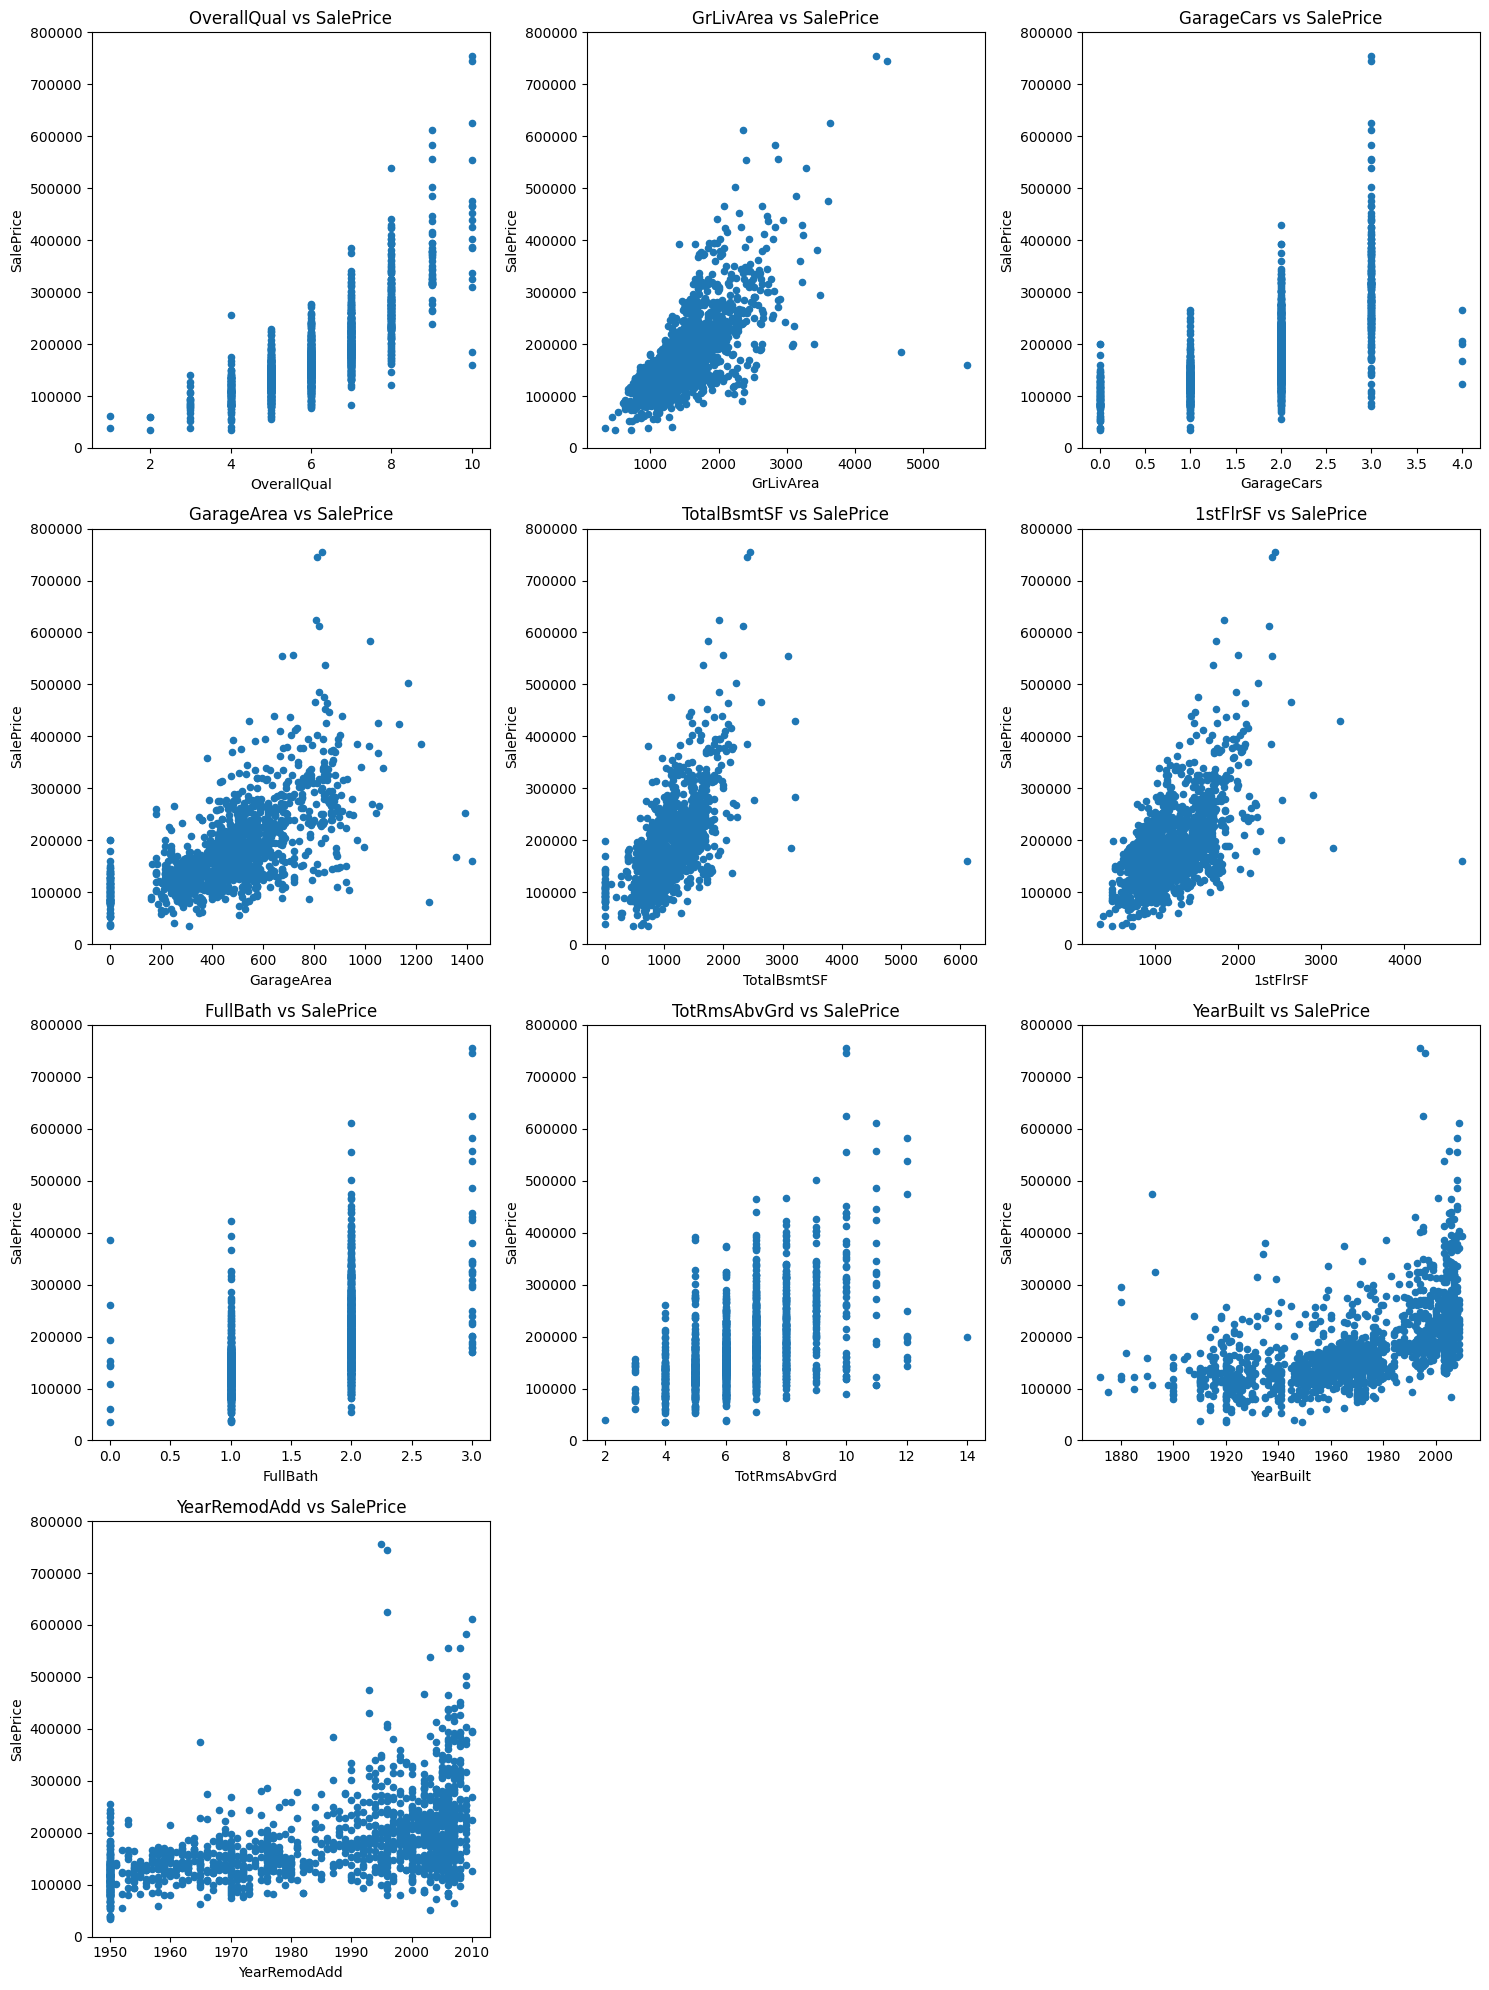

In [79]:
# 1. Identifier les 10 variables les plus corrélées au prix
print("--- TOP 10 CORRÉLATIONS ---")
corr = train_df.select_dtypes(include=['float64', 'int64']).corr()
top_10_cols = corr['SalePrice'].sort_values(ascending=False).head(11).index
top_10_cols = top_10_cols.drop('SalePrice')
print(top_10_cols.tolist())

num_cols = top_10_cols.tolist()

# Create subplots
fig, axes = plt.subplots(nrows=len(num_cols)//3 + 1, ncols=3, figsize=(15, 5*(len(num_cols)//3 + 1)))
axes = axes.flatten()

for i, var in enumerate(num_cols):
    data = pd.concat([train_df['SalePrice'], train_df[var]], axis=1)
    data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000), ax=axes[i])
    axes[i].set_title(f'{var} vs SalePrice')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Analyse détaillée de chaque caractéristique du TOP 10

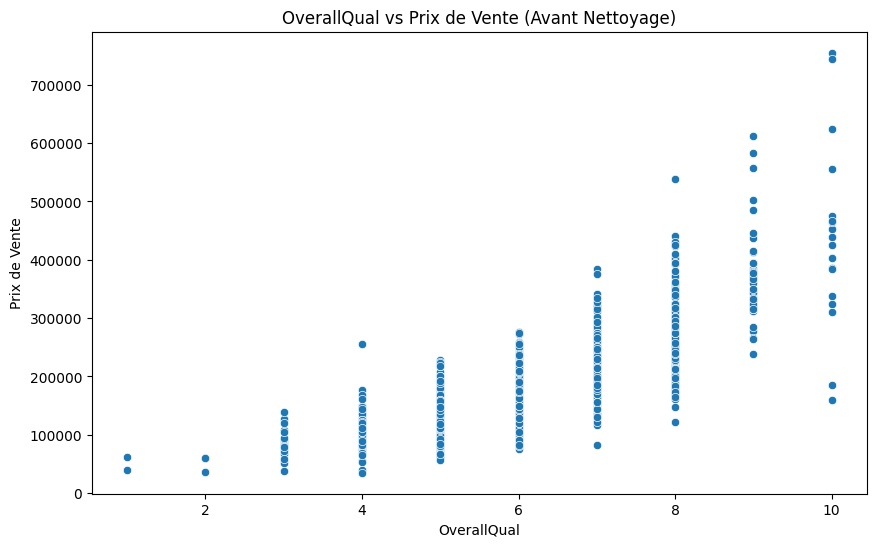

Aucun outlier détecté pour les critères définis


In [80]:
# Caractéristique 1 - OverallQual (Qualité Générale)
feature_name = top_10_cols[0]

# Créer le nuage de points AVANT nettoyage
plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

print("Aucun outlier détecté pour les critères définis")


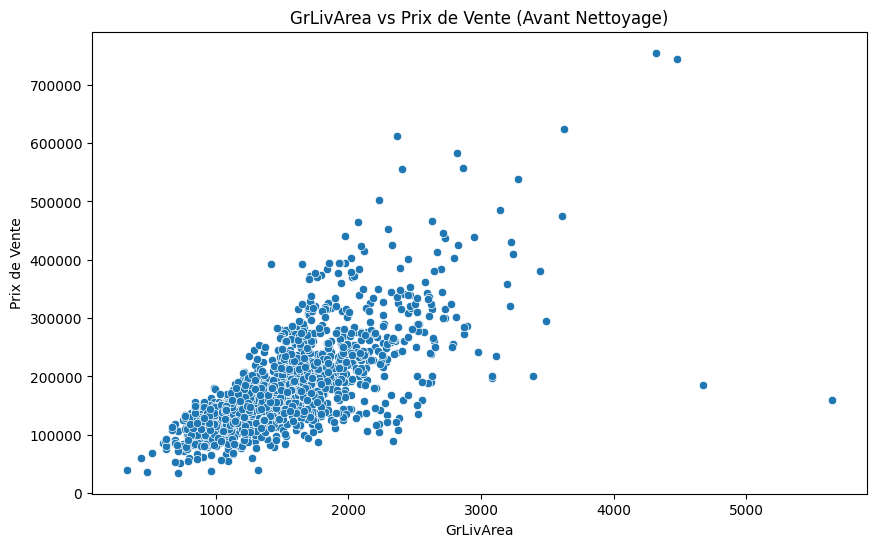


Outliers identifiés : 2
      GrLivArea  SalePrice
523        4676     184750
1298       5642     160000


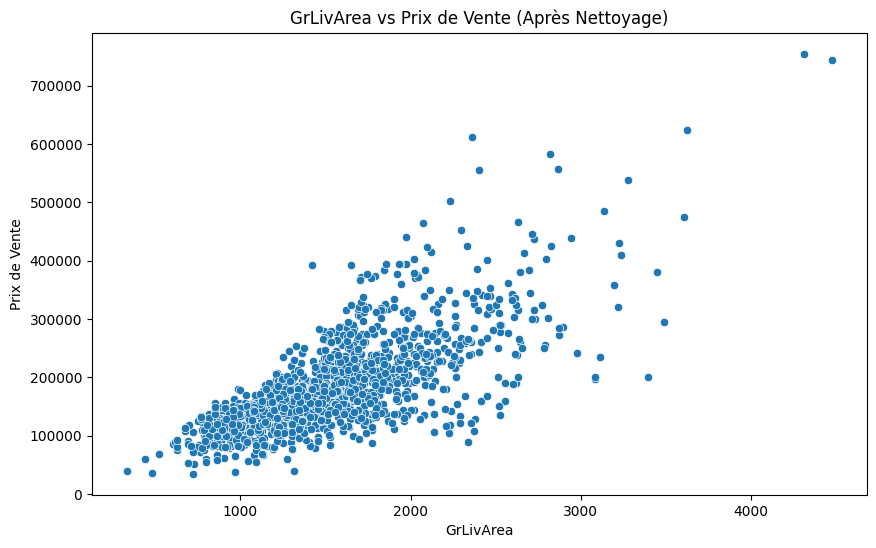

In [81]:
# Caractéristique 2
feature_name = top_10_cols[1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()


outliers = train_df[(train_df[feature_name] > 4000 ) & 
                    (train_df['SalePrice'] < 300000)]
if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)].index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")


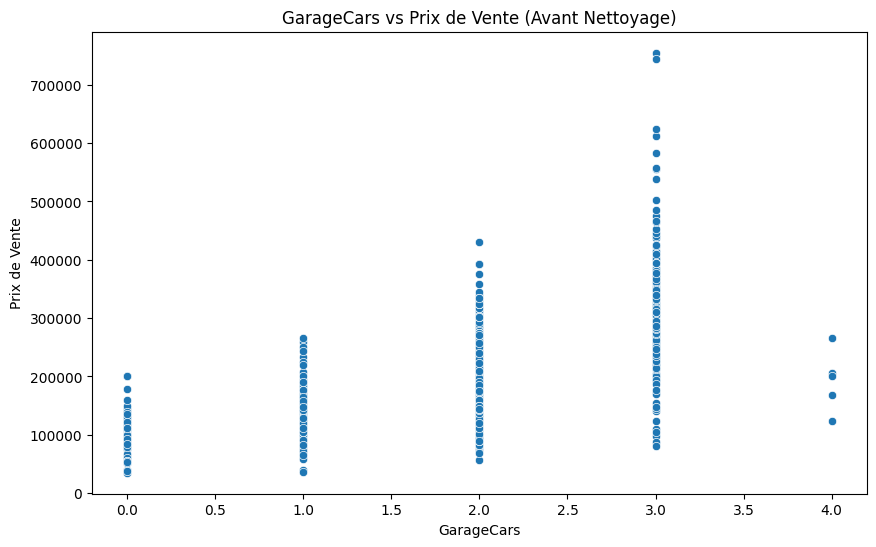


Aucun outlier détecté pour les critères définis


In [82]:
# Caractéristique 3
feature_name = top_10_cols[2]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

outliers = []

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")


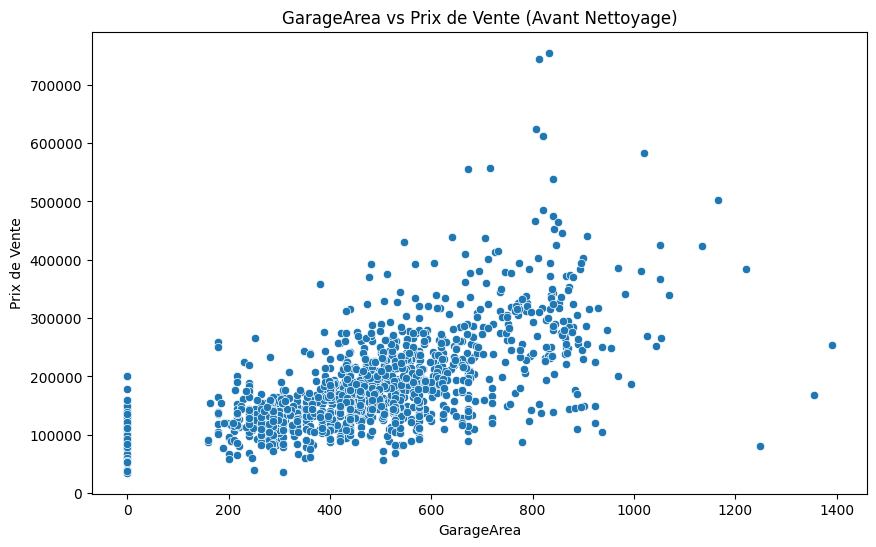


Outliers identifiés : 3
      GarageArea  SalePrice
581         1390     253293
1061        1248      81000
1190        1356     168000


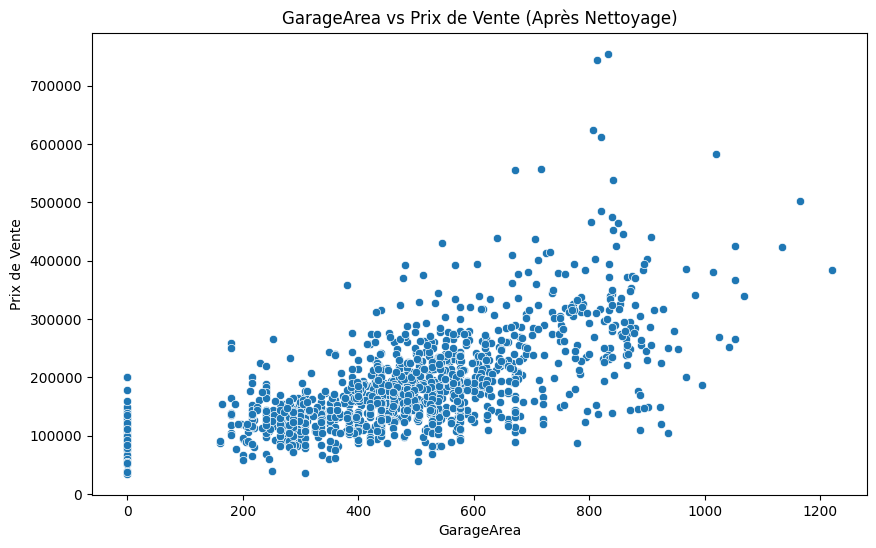

In [83]:
# Caractéristique 4
feature_name = top_10_cols[3]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

outliers = train_df[(train_df[feature_name] > 1200 ) & (train_df['SalePrice'] < 300000)]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")


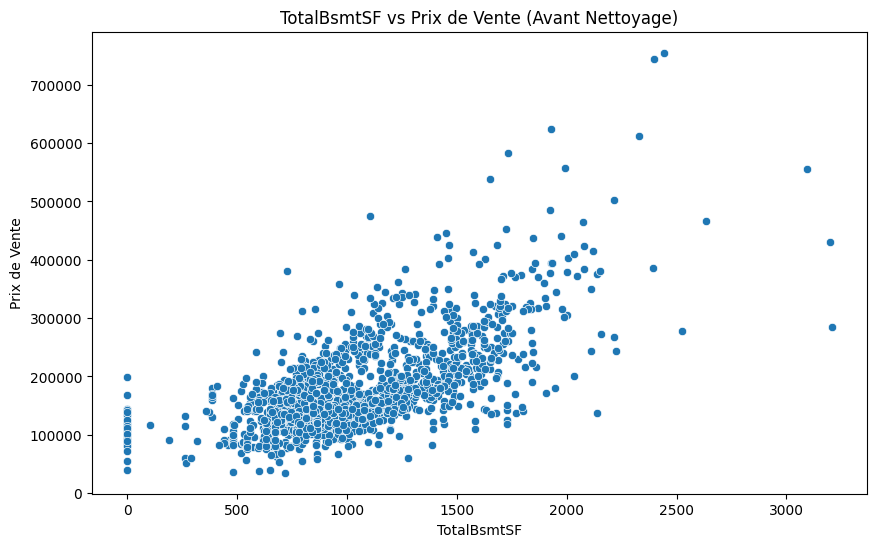


Aucun outlier détecté pour les critères définis


In [84]:
# Caractéristique 5
feature_name = top_10_cols[4]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

outliers = [] #train_df[(train_df[feature_name] > 1200 ) & (train_df['SalePrice'] < 300000)]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")


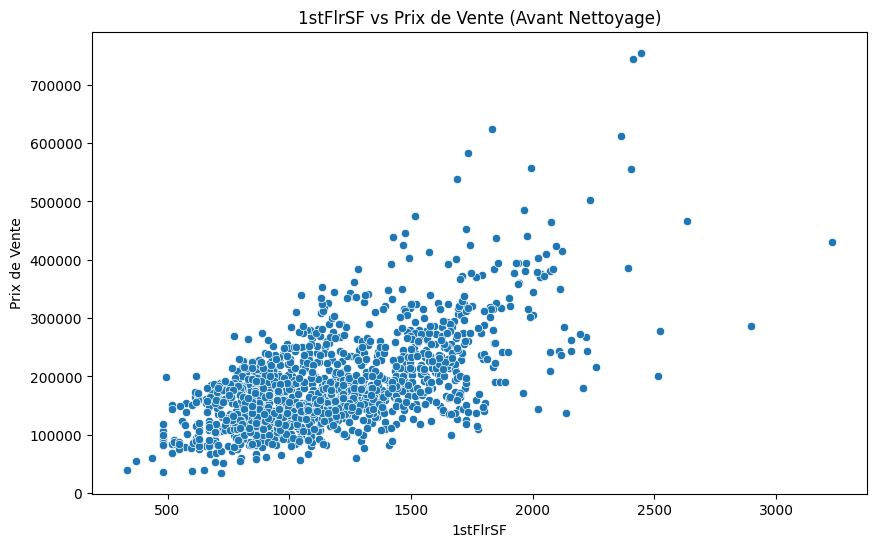


Aucun outlier détecté pour les critères définis


In [85]:
# Caractéristique 6
feature_name = top_10_cols[5]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

outliers = [] #train_df[(train_df[feature_name] > 1200 ) & (train_df['SalePrice'] < 300000)]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")


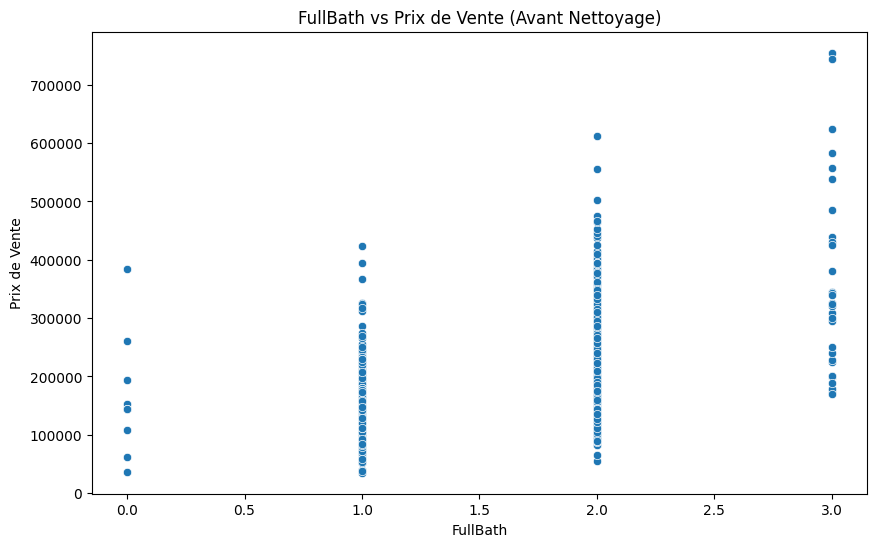


Aucun outlier détecté pour les critères définis


In [86]:
# Caractéristique 7
feature_name = top_10_cols[6]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

outliers = [] #train_df[(train_df[feature_name] > 1200 ) & (train_df['SalePrice'] < 300000)]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")

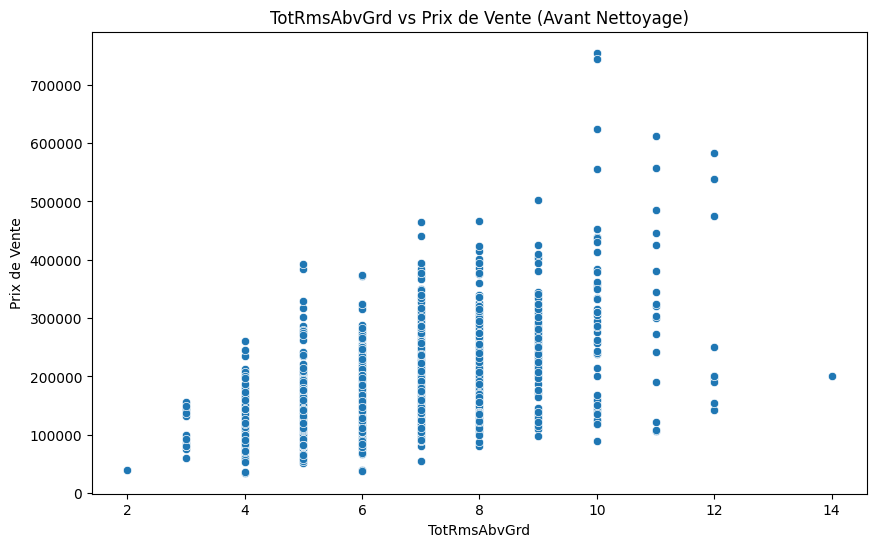


Outliers identifiés : 1
     TotRmsAbvGrd  SalePrice
635            14     200000


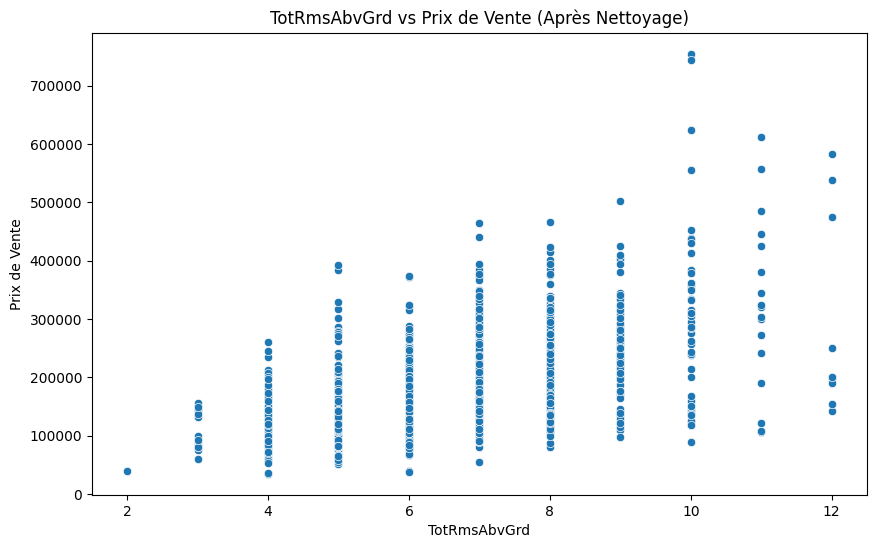

In [87]:
# Caractéristique 8
feature_name = top_10_cols[7]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

outliers = train_df[(train_df[feature_name] >= 14 )]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")


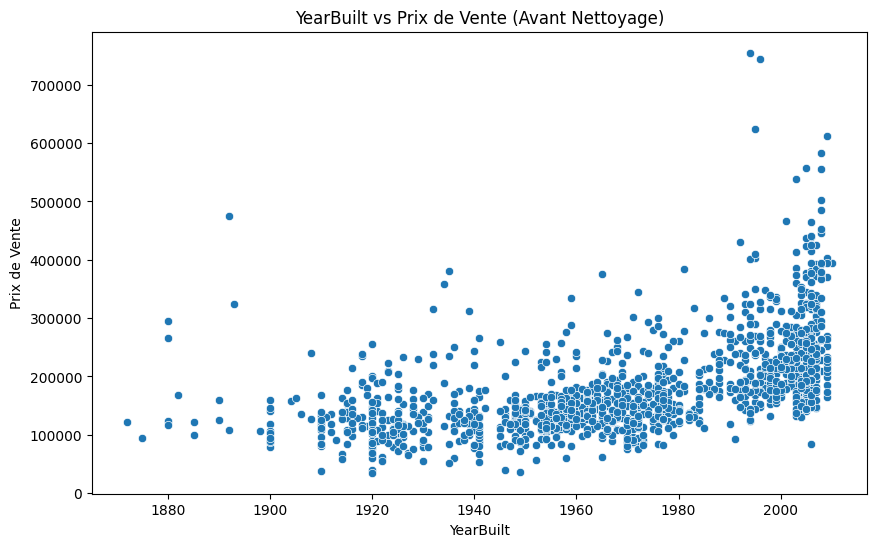


Outliers identifiés : 1
     YearBuilt  SalePrice
185       1892     475000


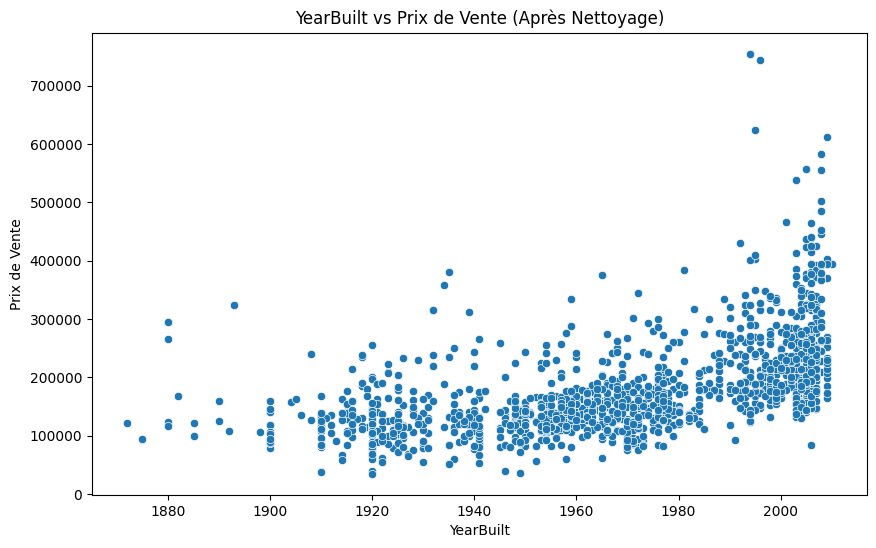

In [88]:
# Caractéristique 9
feature_name = top_10_cols[8]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

outliers = train_df[(train_df[feature_name] <= 1900 ) & (train_df['SalePrice'] > 400000)]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")


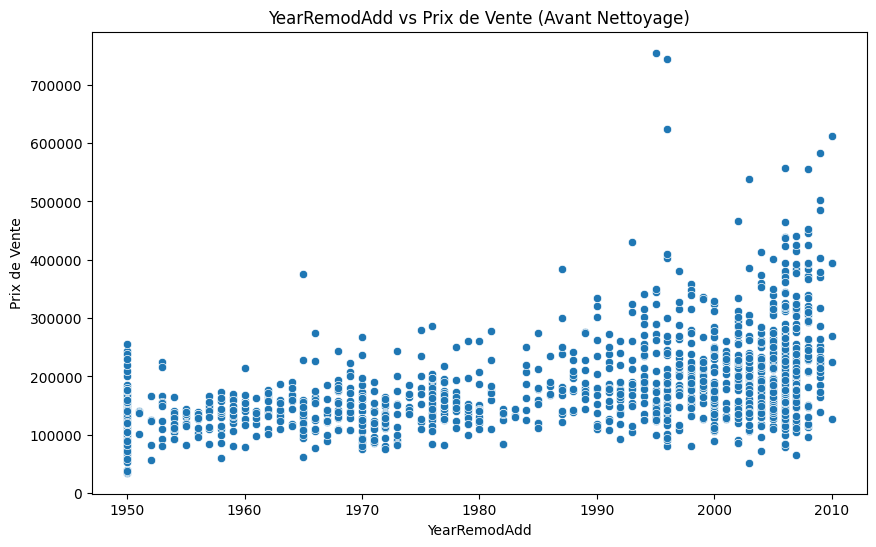


Outliers identifiés : 1
     YearRemodAdd  SalePrice
313          1965     375000


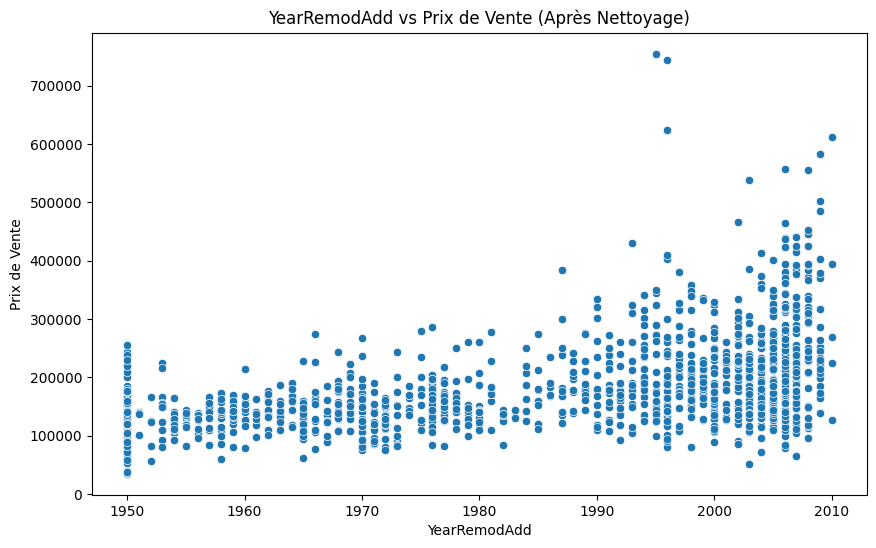

In [89]:
# Caractéristique 10
feature_name = top_10_cols[9]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
plt.title(f"{feature_name} vs Prix de Vente (Avant Nettoyage)")
plt.xlabel(feature_name)
plt.ylabel("Prix de Vente")
plt.show()

outliers = train_df[(train_df[feature_name] <= 1970 ) & (train_df['SalePrice'] >= 300000)]

if len(outliers) > 0:
    print(f"\nOutliers identifiés : {len(outliers)}")
    print(outliers[[feature_name, 'SalePrice']])
    train_df = train_df.drop(outliers.index)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=train_df[feature_name], y=train_df['SalePrice'])
    plt.title(f"{feature_name} vs Prix de Vente (Après Nettoyage)")
    plt.xlabel(feature_name)
    plt.ylabel("Prix de Vente")
    plt.show()
else:
    print(f"\nAucun outlier détecté pour les critères définis")


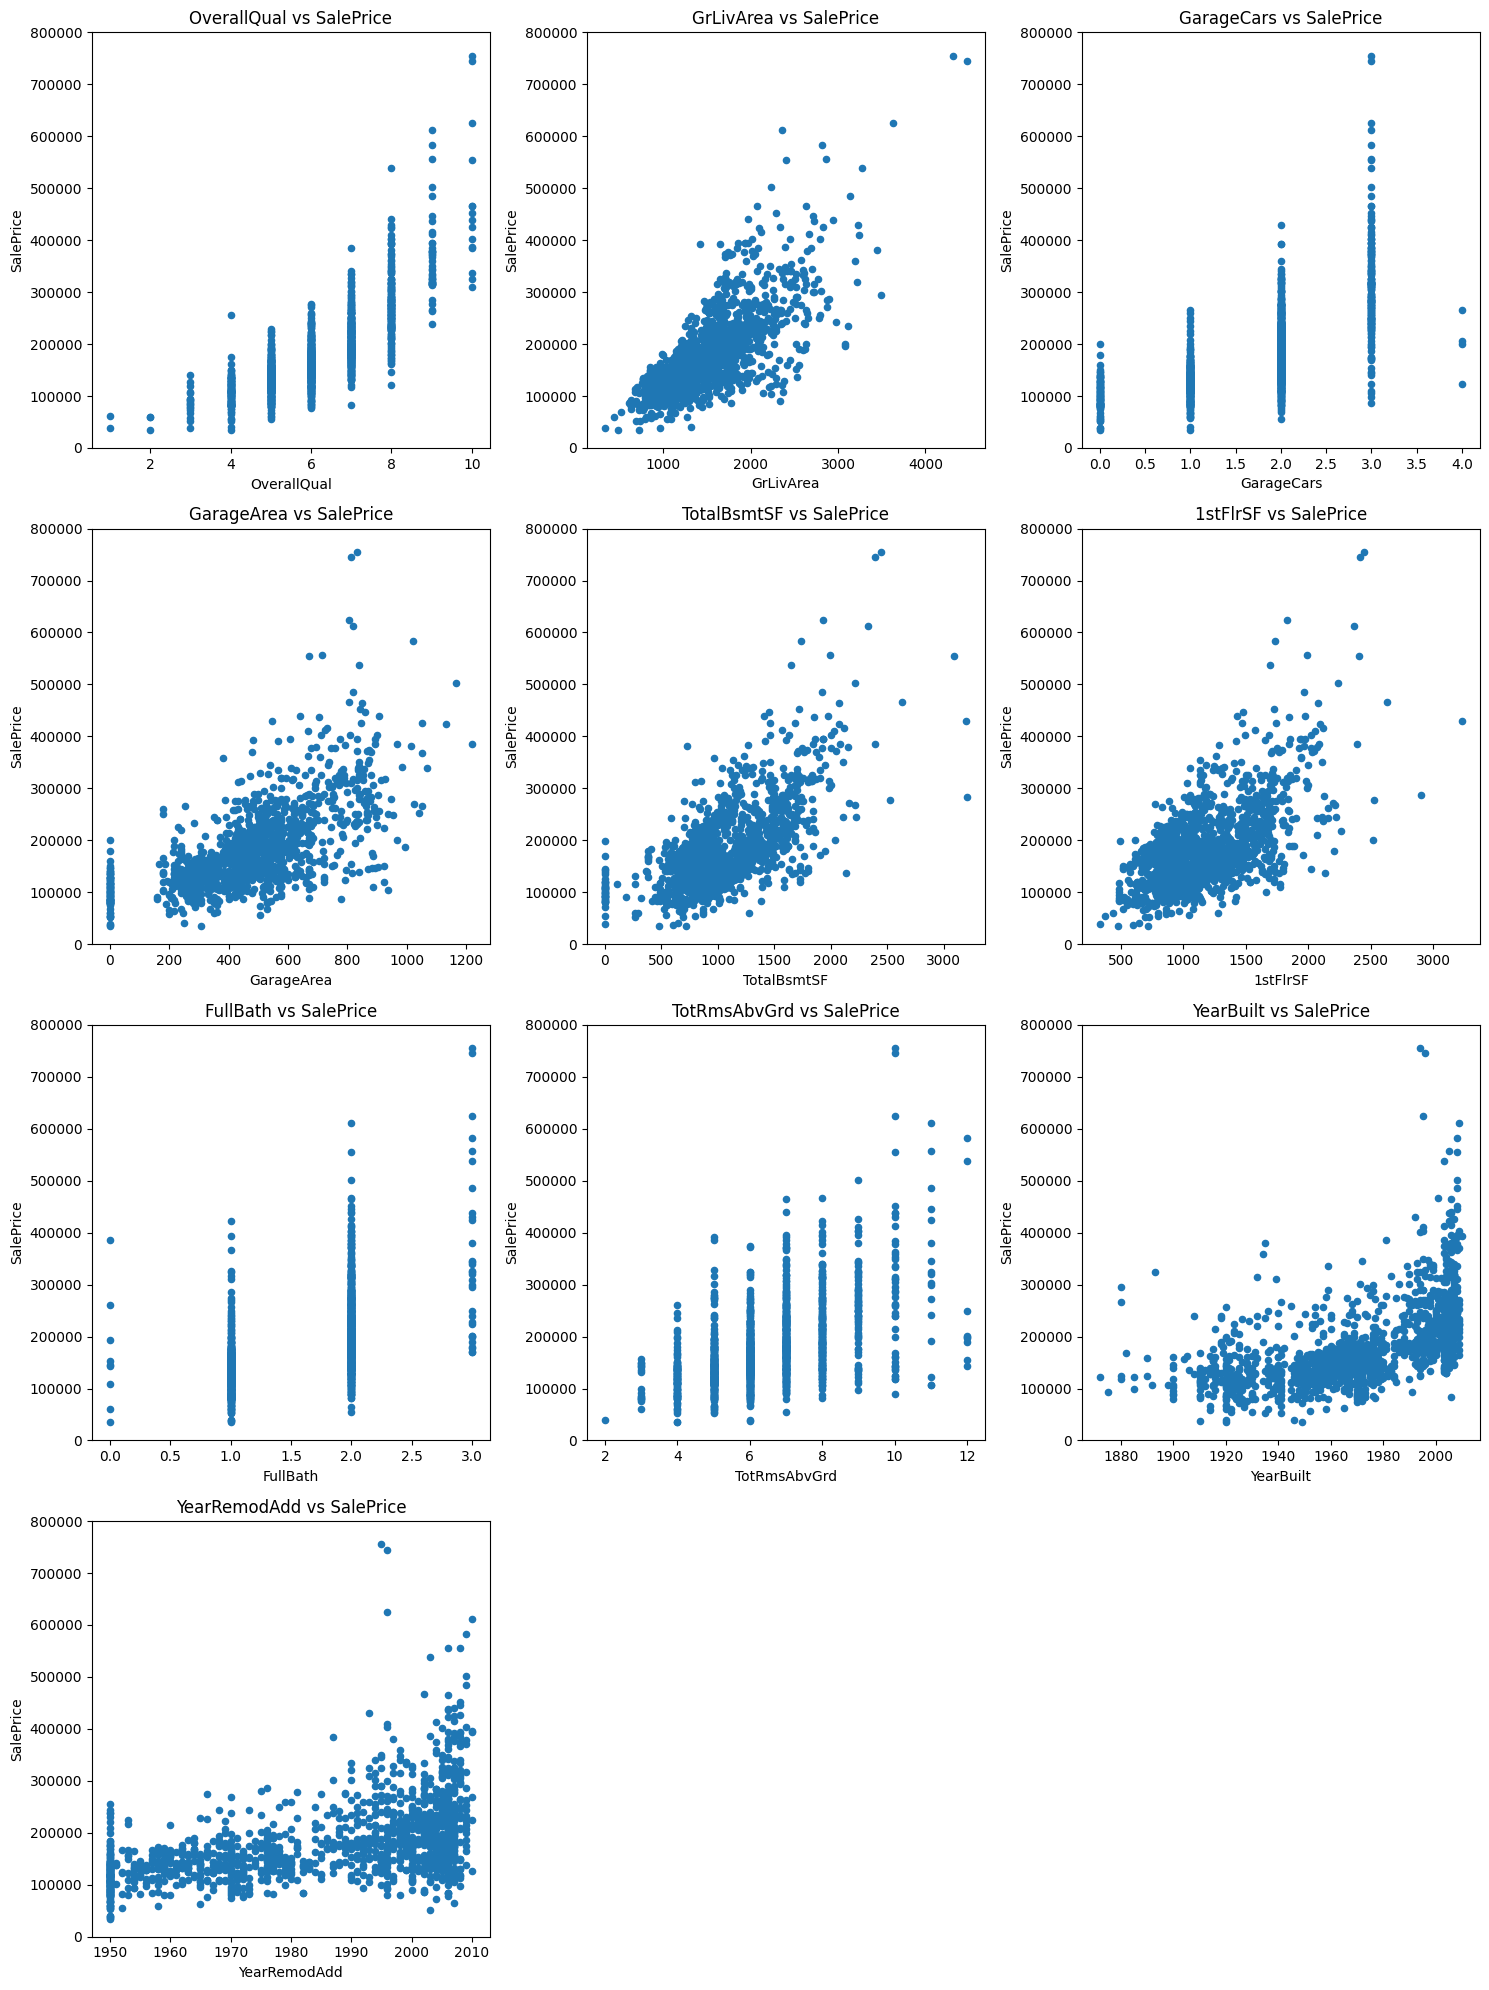

In [90]:
# Create subplots
fig, axes = plt.subplots(nrows=len(num_cols)//3 + 1, ncols=3, figsize=(15, 5*(len(num_cols)//3 + 1)))
axes = axes.flatten()

for i, var in enumerate(num_cols):
    data = pd.concat([train_df['SalePrice'], train_df[var]], axis=1)
    data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000), ax=axes[i])
    axes[i].set_title(f'{var} vs SalePrice')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Pipeline 

In [91]:
# 1. Séparer la cible
X = train_df.drop(['SalePrice', 'Id'], axis=1) # On enlève le prix et l'ID (inutile)
y = train_df['SalePrice']

# 2. Transformer la cible (Log-Transformation)
# On utilise log1p (log(1+x)) pour éviter les erreurs si prix = 0 (rare mais bonne pratique)
y_log = np.log1p(y)

# Vérification visuelle rapide
print(f"Skewness avant : {y.skew()}")
print(f"Skewness après : {y_log.skew()}") # Devrait être très proche de 0

Skewness avant : 1.8884267521341112
Skewness après : 0.11725223241298499


In [92]:
# Sélection automatique des colonnes
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print(f"Nombre de variables numériques : {len(numeric_features)}")
print(f"Nombre de variables catégorielles : {len(categorical_features)}")

Nombre de variables numériques : 36
Nombre de variables catégorielles : 43


In [93]:
# A. Pipeline pour les variables numériques
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Remplace NaN par la médiane
    ('scaler', RobustScaler())                     # Mise à l'échelle robuste aux outliers
])

# B. Pipeline pour les variables catégorielles
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')), # Remplace NaN par "None"
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # Transforme en chiffres
])

# C. Assemblage du processeur final
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

## Entraînement du Modèle (Baseline)

In [94]:
# Séparation Train/Test (partagée pour tous les modèles)
print("=== PRÉPARATION DES DONNÉES ===")
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")

# Split pour early stopping (validation interne)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print(f"Train : {X_tr.shape[0]} | Validation : {X_val.shape[0]}")

=== PRÉPARATION DES DONNÉES ===
Train : 1161 | Test : 291
Train : 928 | Validation : 233


#### Ridge

In [95]:
# 1. Création du Pipeline Ridge initial - BASELINE
ridge_model = Ridge(alpha=1.0)
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ridge_model)
])

# 2. Entraînement baseline
ridge_pipeline.fit(X_train, y_train)

# 3. Évaluation baseline
y_pred_ridge_baseline = ridge_pipeline.predict(X_test)
rmse_ridge_baseline = np.sqrt(mean_squared_error(y_test, y_pred_ridge_baseline))

print(f"Résultat du modèle Ridge avant optimisation : {rmse_ridge_baseline:.5f}")

# 4. Définition de la grille de paramètres pour Ridge
param_grid_ridge = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
}

# 5. Configurer la recherche
grid_search_ridge = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid_ridge,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 6. Lancer la recherche
print("Recherche des meilleurs paramètres pour Ridge...")
grid_search_ridge.fit(X_train, y_train)

# 7. Résultats
print(f"\nMeilleurs paramètres Ridge trouvés : {grid_search_ridge.best_params_}")
best_score_ridge = -grid_search_ridge.best_score_
print(f"Meilleur score CV (RMSE) : {best_score_ridge:.5f}")

# 8. Test final sur le jeu de test
best_ridge_pipeline = grid_search_ridge.best_estimator_
y_pred_ridge = best_ridge_pipeline.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"Score final sur Test (Optimisé) : {rmse_ridge:.5f}")

Résultat du modèle Ridge avant optimisation : 0.12473
Recherche des meilleurs paramètres pour Ridge...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Recherche des meilleurs paramètres pour Ridge...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Meilleurs paramètres Ridge trouvés : {'model__alpha': 10.0}
Meilleur score CV (RMSE) : 0.11562
Score final sur Test (Optimisé) : 0.12445

Meilleurs paramètres Ridge trouvés : {'model__alpha': 10.0}
Meilleur score CV (RMSE) : 0.11562
Score final sur Test (Optimisé) : 0.12445


#### XGCBoost

In [96]:
# 1. Définition du nouveau modèle (XGBoost)
# On utilise des paramètres standard pour commencer
xgb_model = XGBRegressor(
    n_estimators=1000,     # Nombre d'arbres (Semaine 11)
    learning_rate=0.05,    # Vitesse d'apprentissage
    n_jobs=-1,             # Utiliser tous les processeurs
    random_state=42
)

# 2. Création du Pipeline XGBoost
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

# 3. Entraînement
xgb_pipeline.fit(X_train, y_train)

# 4. Évaluation
y_pred_xgb = xgb_pipeline.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"Résultat du modèle XGBoost): {rmse_xgb:.5f}")

Résultat du modèle XGBoost): 0.13526


In [97]:
# 1. Définir la grille des paramètres à tester
# On teste différentes profondeurs et vitesses d'apprentissage
param_grid = {
    'model__n_estimators': [1000, 1500],  # Nombre d'arbres
    'model__max_depth': [3, 5],           # Profondeur des arbres (éviter le sur-apprentissage)
    'model__learning_rate': [0.01, 0.05], # Vitesse (plus c'est petit, plus c'est précis mais lent)
    'model__subsample': [0.7]             # Pour éviter le sur-apprentissage (bagging interne)
}

# 2. Configurer la recherche
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error', # Métrique de Kaggle
    cv=3,                                  # Validation croisée à 3 plis
    n_jobs=-1,                             # Utiliser tous les processeurs
    verbose=1
)

# 3. Lancer la recherche
print("Recherche des meilleurs paramètres en cours...")
grid_search.fit(X_train, y_train)

# 4. Résultats
print(f"\nMeilleurs paramètres trouvés : {grid_search.best_params_}")
best_score = -grid_search.best_score_
print(f"Meilleur score CV (RMSE) : {best_score:.5f}")

# 5. Test final sur le jeu de test avec le meilleur modèle
best_xgb_pipeline = grid_search.best_estimator_
y_pred_best = best_xgb_pipeline.predict(X_test)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"Score final sur Test (Optimisé) : {rmse_best:.5f}")

Recherche des meilleurs paramètres en cours...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Meilleurs paramètres trouvés : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 1000, 'model__subsample': 0.7}
Meilleur score CV (RMSE) : 0.12030
Score final sur Test (Optimisé) : 0.12616

Meilleurs paramètres trouvés : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 1000, 'model__subsample': 0.7}
Meilleur score CV (RMSE) : 0.12030
Score final sur Test (Optimisé) : 0.12616


#### LightGBM

In [98]:
# 1. Création du Pipeline LightGBM initial - BASELINE
lgbm_model = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=6, random_state=42, verbose=-1)
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lgbm_model)
])

# 2. Entraînement baseline
lgbm_pipeline.fit(X_train, y_train)

# 3. Évaluation baseline
y_pred_lgbm_baseline = lgbm_pipeline.predict(X_test)
rmse_lgbm_baseline = np.sqrt(mean_squared_error(y_test, y_pred_lgbm_baseline))

print(f"Résultat du modèle LightGBM avant optimisation : {rmse_lgbm_baseline:.5f}")

# 4. Définition de la grille de paramètres pour LightGBM
param_grid_lgbm = {
    'model__n_estimators': [300, 500],
    'model__max_depth': [3, 5],
    'model__num_leaves': [4, 6],
    'model__learning_rate': [0.01, 0.05]
}

# 5. Configurer la recherche
grid_search_lgbm = GridSearchCV(
    estimator=lgbm_pipeline,
    param_grid=param_grid_lgbm,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 6. Lancer la recherche
print("Recherche des meilleurs paramètres pour LightGBM...")
grid_search_lgbm.fit(X_train, y_train)

# 7. Résultats
print(f"\nMeilleurs paramètres LightGBM trouvés : {grid_search_lgbm.best_params_}")
best_score_lgbm = -grid_search_lgbm.best_score_
print(f"Meilleur score CV (RMSE) : {best_score_lgbm:.5f}")

# 8. Test final sur le jeu de test
best_lgbm_pipeline = grid_search_lgbm.best_estimator_
y_pred_lgbm = best_lgbm_pipeline.predict(X_test)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))

print(f"Score final sur Test (Optimisé) : {rmse_lgbm:.5f}")

c:\Users\vaneg_wqyq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Résultat du modèle LightGBM avant optimisation : 0.12781
Recherche des meilleurs paramètres pour LightGBM...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Meilleurs paramètres LightGBM trouvés : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 500, 'model__num_leaves': 4}
Meilleur score CV (RMSE) : 0.12389
Score final sur Test (Optimisé) : 0.12706

Meilleurs paramètres LightGBM trouvés : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 500, 'model__num_leaves': 4}
Meilleur score CV (RMSE) : 0.12389
Score final sur Test (Optimisé) : 0.12706


c:\Users\vaneg_wqyq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


#### Lasso 

In [99]:
# 1. Création du Pipeline Lasso initial - BASELINE
lasso_model = Lasso(alpha=0.1, max_iter=5000, random_state=42)
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lasso_model)
])

# 2. Entraînement baseline
lasso_pipeline.fit(X_train, y_train)

# 3. Évaluation baseline
y_pred_lasso_baseline = lasso_pipeline.predict(X_test)
rmse_lasso_baseline = np.sqrt(mean_squared_error(y_test, y_pred_lasso_baseline))

print(f"Résultat du modèle Lasso avant optimisation : {rmse_lasso_baseline:.5f}")

# 4. Définition de la grille de paramètres pour Lasso
param_grid_lasso = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
}

# 5. Configurer la recherche
grid_search_lasso = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid_lasso,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 6. Lancer la recherche
print("Recherche des meilleurs paramètres pour Lasso...")
grid_search_lasso.fit(X_train, y_train)

# 7. Résultats
print(f"\nMeilleurs paramètres Lasso trouvés : {grid_search_lasso.best_params_}")
best_score_lasso = -grid_search_lasso.best_score_
print(f"Meilleur score CV (RMSE) : {best_score_lasso:.5f}")

# 8. Test final sur le jeu de test
best_lasso_pipeline = grid_search_lasso.best_estimator_
y_pred_lasso = best_lasso_pipeline.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print(f"Score final sur Test (Optimisé) : {rmse_lasso:.5f}")

Résultat du modèle Lasso avant optimisation : 0.23280
Recherche des meilleurs paramètres pour Lasso...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Meilleurs paramètres Lasso trouvés : {'model__alpha': 0.001}
Meilleur score CV (RMSE) : 0.11547
Score final sur Test (Optimisé) : 0.12620

Meilleurs paramètres Lasso trouvés : {'model__alpha': 0.001}
Meilleur score CV (RMSE) : 0.11547
Score final sur Test (Optimisé) : 0.12620


#### Mélange 

In [100]:
# 1. Générer les prédictions sur le jeu de test
pred_ridge = best_ridge_pipeline.predict(X_test)
pred_xgb = best_xgb_pipeline.predict(X_test)
pred_lgbm = best_lgbm_pipeline.predict(X_test)
pred_lasso = best_lasso_pipeline.predict(X_test)

# 2. Recherche des poids optimaux via validation croisée
from sklearn.linear_model import LinearRegression

# Créer une matrice des prédictions (4 modèles)
X_meta = np.column_stack([pred_ridge, pred_xgb, pred_lgbm, pred_lasso])

# Entraîner un modèle linéaire pour trouver les meilleurs poids
meta_model = LinearRegression()
meta_model.fit(X_meta, y_test)

# Les coefficients du modèle linéaire sont nos poids optimaux
weights = meta_model.coef_
weights_normalized = weights / weights.sum()  # Normaliser les poids

print(f"\nPoids optimaux trouvés :")
print(f"  Ridge  : {weights_normalized[0]:.4f}")
print(f"  XGBoost: {weights_normalized[1]:.4f}")
print(f"  LightGBM: {weights_normalized[2]:.4f}")
print(f"  Lasso  : {weights_normalized[3]:.4f}")

# 3. Appliquer les poids optimaux
final_pred = (weights_normalized[0] * pred_ridge + 
              weights_normalized[1] * pred_xgb + 
              weights_normalized[2] * pred_lgbm + 
              weights_normalized[3] * pred_lasso)

# 4. Calculer le score final
rmse_blend = np.sqrt(mean_squared_error(y_test, final_pred))

print(f"\n" + "="*60)
print("RÉSUMÉ DES PERFORMANCES")
print("="*60)
print(f"Ridge         : {rmse:.5f}")
print(f"XGBoost       : {rmse_best:.5f}")
print(f"LightGBM      : {rmse_lgbm:.5f}")
print(f"Lasso         : {rmse_lasso:.5f}")
print(f"Blending (opt): {rmse_blend:.5f}")
print(f"\nMeilleur score : {min(rmse, rmse_best, rmse_lgbm, rmse_lasso, rmse_blend):.5f}")


Poids optimaux trouvés :
  Ridge  : 0.2527
  XGBoost: 0.3696
  LightGBM: 0.1017
  Lasso  : 0.2761

RÉSUMÉ DES PERFORMANCES
Ridge         : 0.12473
XGBoost       : 0.12616
LightGBM      : 0.12706
Lasso         : 0.12620
Blending (opt): 0.12046

Meilleur score : 0.12046


c:\Users\vaneg_wqyq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [103]:
# 1. Charger les données de test (celles sans le prix)
test_df = pd.read_csv('input/house-prices-advanced-regression-techniques/test.csv')

# Sauvegarder les IDs pour le fichier final
test_ids = test_df['Id']

# 2. Générer les prédictions sur le jeu de test Kaggle
pred_ridge_test = best_ridge_pipeline.predict(test_df)
pred_xgb_test = best_xgb_pipeline.predict(test_df)
pred_lgbm_test = best_lgbm_pipeline.predict(test_df)
pred_lasso_test = best_lasso_pipeline.predict(test_df)

# 3. Appliquer les mêmes poids optimaux trouvés pendant l'entraînement
final_pred_log = (weights_normalized[0] * pred_ridge_test + 
                  weights_normalized[1] * pred_xgb_test + 
                  weights_normalized[2] * pred_lgbm_test + 
                  weights_normalized[3] * pred_lasso_test)

# 4. Inverser la transformation log (puisqu'on avait fait np.log1p)
final_pred = np.expm1(final_pred_log)

# 5. Créer le fichier de soumission
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_pred
})

# Sauvegarde
submission.to_csv('submission.csv', index=False)
print("\n✅ Fichier 'submission.csv' généré avec succès !")
print(f"Nombre de prédictions : {len(submission)}")


✅ Fichier 'submission.csv' généré avec succès !
Nombre de prédictions : 1459


c:\Users\vaneg_wqyq\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
